Instalasi, Import, dan Upload File

In [1]:
# Sel 1: Instalasi Library
!apt-get install tesseract-ocr
!pip install pytesseract opencv-python matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [83]:
import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Silakan upload gambar ijazah (bisa pilih lebih dari satu file sekaligus):")
uploaded = files.upload()

# Membuat dictionary global untuk menyimpan data setiap gambar di setiap tahapan
data_ijazah = {}
for filename in uploaded.keys():
    data_ijazah[filename] = {}
print(f"\nBerhasil memuat {len(data_ijazah)} file. Lanjut ke Sel 3.")

Silakan upload gambar ijazah (bisa pilih lebih dari satu file sekaligus):


Saving 03_Blurred (1).jpg to 03_Blurred (1).jpg
Saving 05_LowResolution_Upsampled (1).jpg to 05_LowResolution_Upsampled (1).jpg
Saving 06_Faded_Underexposed (1).jpg to 06_Faded_Underexposed (1).jpg
Saving 07_ColorShift_WarmTint (1).jpg to 07_ColorShift_WarmTint (1).jpg
Saving 08_JPEGCompression_Artifacts (1).jpg to 08_JPEGCompression_Artifacts (1).jpg
Saving 01_HighQuality_Enhanced.jpg to 01_HighQuality_Enhanced (1).jpg
Saving 02_LowContrast (1).jpg to 02_LowContrast (1) (1).jpg
Saving 04_HighNoise (1).jpg to 04_HighNoise (1) (1).jpg
Saving 09_CombinedDegradation (1).jpg to 09_CombinedDegradation (1) (1).jpg

Berhasil memuat 9 file. Lanjut ke Sel 3.


Pipeline Pre-Processing
Sel ini memproses semua gambar yang telah di-upload: memutar gambar 90 derajat agar teksnya horizontal, menjadikannya hitam-putih, dan menerapkan CLAHE untuk meratakan pencahayaan.

In [84]:
# ==========================================
# SEL 3: PIPELINE PRE-PROCESSING
# ==========================================
for filename, data in data_ijazah.items():
    img = cv2.imread(filename)
    if img is None:
        print(f"Gagal memuat gambar: {filename}")
        continue

    # Rotasi 90 derajat searah jarum jam (Sesuai template ijazah vertikal)
    img_rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

    # Grayscale & CLAHE Enhancement
    gray = cv2.cvtColor(img_rotated, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    # Simpan hasil pre-processing ke dictionary
    data['enhanced_gray'] = clahe.apply(gray)

print("Pre-processing (Rotasi & Enhancement) selesai untuk semua file.")

Pre-processing (Rotasi & Enhancement) selesai untuk semua file.


Pemotongan Area (ROI)
Berdasarkan gambar yang sudah di-enhancement, sel ini memotong bagian kiri-bawah (Nomor Ijazah) dan bagian tengah-kiri (Tanda Tangan Rektor).

In [85]:
# ==========================================
# SEL 4: PEMOTONGAN AREA (ROI)
# ==========================================
for filename, data in data_ijazah.items():
    # Load gambar asli
    img = cv2.imread(filename)
    if img is None:
        print(f"Gagal memuat {filename}")
        continue

    # 1. Grayscale & Enhancement (TANPA ROTASI SAMA SEKALI)
    # OpenCV otomatis membaca gambar ini dalam orientasi Landscape
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced_gray = clahe.apply(gray)
    data['enhanced_gray'] = enhanced_gray

    H, W = enhanced_gray.shape

    # 2. Potong berdasarkan koordinat Matriks Landscape
    # Area Nomor Ijazah (Posisinya di KIRI ATAS pada matriks OpenCV)
    # Y: 2% - 15% (Atas) | X: 2% - 45% (Kiri)
    data['roi_nomor'] = enhanced_gray[int(H * 0.89) : int(H * 0.98), int(W * 0.02) : int(W * 0.30)]

    # Area Tanda Tangan Rektor (Posisinya di KIRI BAWAH pada matriks OpenCV)
    # Y: 65% - 95% (Bawah) | X: 10% - 50% (Kiri)
    data['roi_ttd'] = enhanced_gray[int(H * 0.65) : int(H * 0.85), int(W * 0.10) : int(W * 0.43)]

print("Perbaikan Pre-Processing & Pemotongan Area Selesai.")

Perbaikan Pre-Processing & Pemotongan Area Selesai.


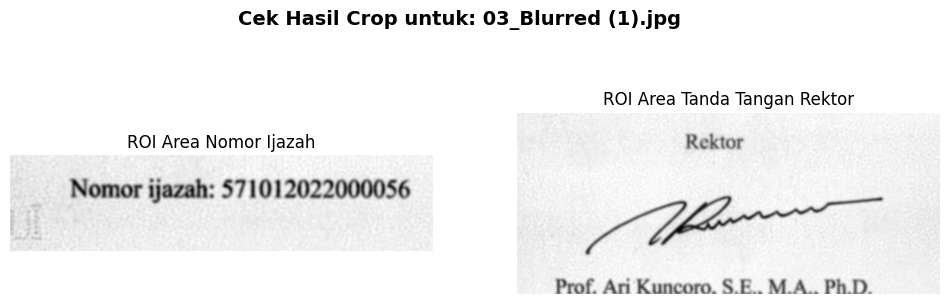

--------------------------------------------------


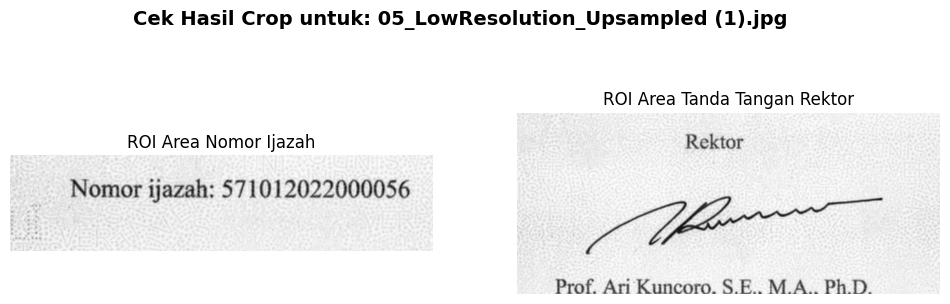

--------------------------------------------------


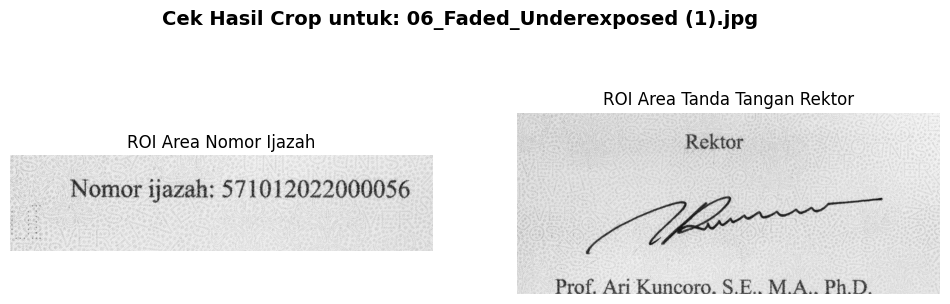

--------------------------------------------------


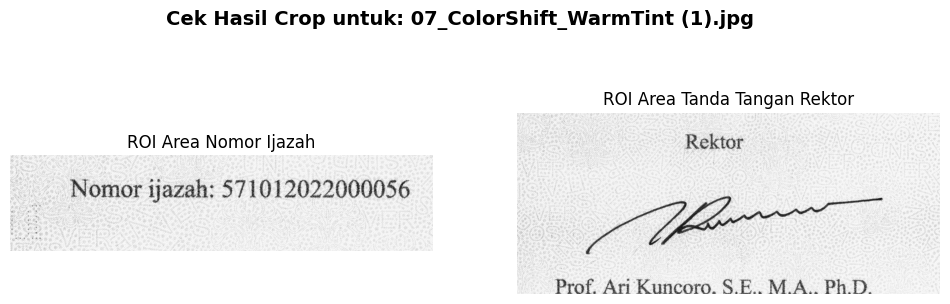

--------------------------------------------------


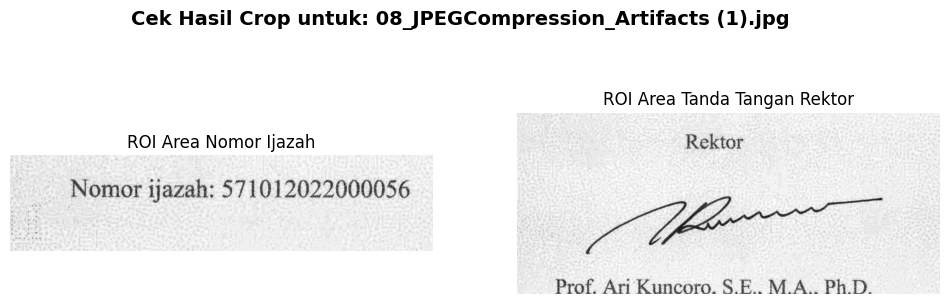

--------------------------------------------------


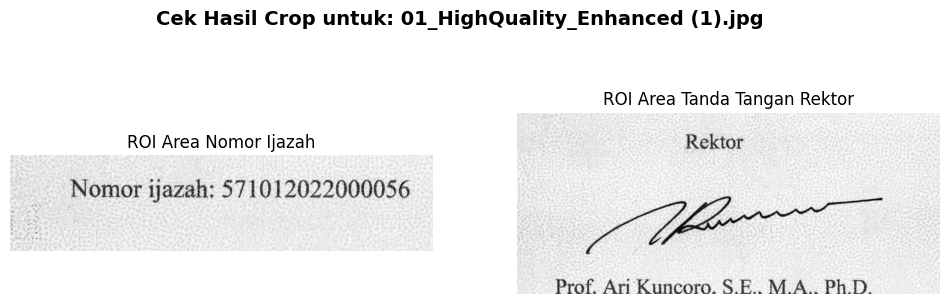

--------------------------------------------------


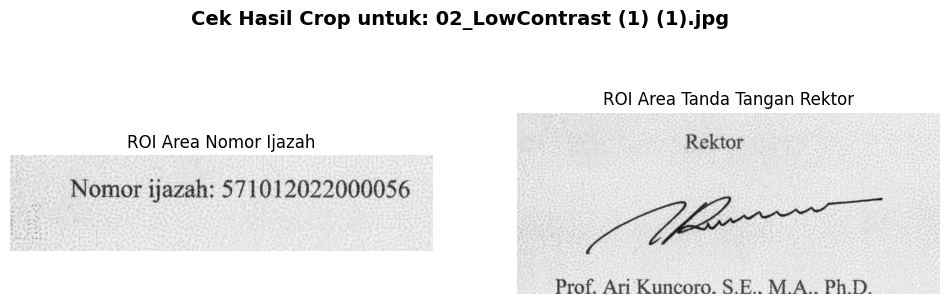

--------------------------------------------------


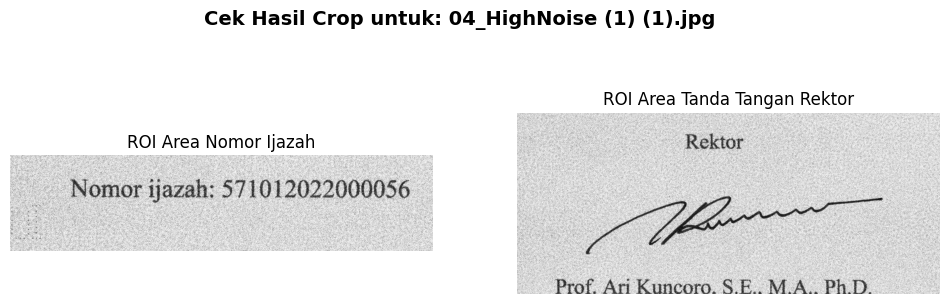

--------------------------------------------------


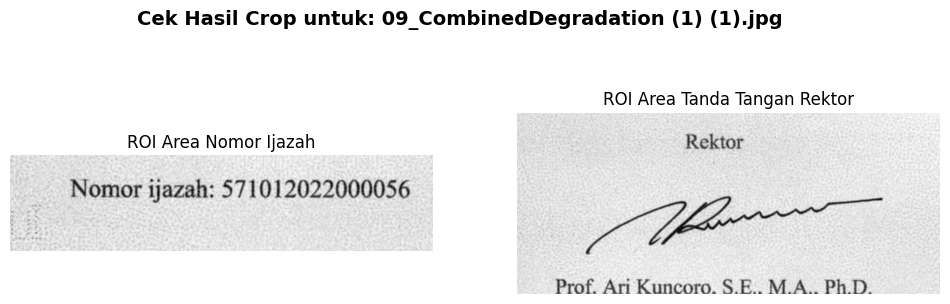

--------------------------------------------------


In [86]:
import matplotlib.pyplot as plt

for filename, data in data_ijazah.items():
    if 'roi_nomor' not in data or 'roi_ttd' not in data:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Cek Hasil Crop untuk: {filename}", fontsize=14, fontweight='bold')

    # Menampilkan potongan area nomor ijazah
    ax[0].imshow(data['roi_nomor'], cmap='gray')
    ax[0].set_title('ROI Area Nomor Ijazah')
    ax[0].axis('off')

    # Menampilkan potongan area tanda tangan
    ax[1].imshow(data['roi_ttd'], cmap='gray')
    ax[1].set_title('ROI Area Tanda Tangan Rektor')
    ax[1].axis('off')

    plt.show()
    print("-" * 50)

Ekstraksi Nomor (OCR)
Area yang sudah dipotong tadi diberikan Adaptive Thresholding agar teksnya sangat tajam, lalu dibaca oleh Tesseract OCR.

In [87]:
# ==========================================
# SEL 5: EKSTRAKSI NOMOR (OCR)
# ==========================================
for filename, data in data_ijazah.items():
    if 'roi_nomor' not in data: continue

    roi_nomor = data['roi_nomor']

    # 1. Pembesaran Imej (Upscaling)
    # Tesseract berfungsi lebih baik pada imej beresolusi tinggi (sekitar 300 DPI).
    # Oleh itu, kita membesarkan saiz ROI ini.
    roi_nomor_large = cv2.resize(roi_nomor, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    # 2. Penyingkiran Hingar (Noise Removal)
    # Mengurangkan gangguan pada latar belakang sebelum proses binarization.
    roi_blurred = cv2.GaussianBlur(roi_nomor_large, (5, 5), 0)

    # 3. Otsu Thresholding
    # Menggunakan kaedah Otsu sering kali memberikan hasil yang lebih bersih berbanding Adaptive Thresholding
    # jika pencahayaan pada ROI tersebut sudah seragam.
    _, thresh_nomor = cv2.threshold(roi_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)



    # Ekstraksi teks menggunakan pytesseract
    # --psm 7: Menganggap imej sebagai satu baris teks tunggal.
    # --psm 6: Menganggap imej sebagai satu blok teks yang seragam. Boleh cuba ini jika 7 gagal.
    # whitelist: Hanya membenarkan huruf, nombor, ruang, tanda titik bertindih dan sengkang dibaca.
    custom_config = r'--psm 7 -c tessedit_char_whitelist="ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789 :-"'
    nomor_text = pytesseract.image_to_string(thresh_nomor, config=custom_config).strip()

    # Membersihkan teks (membuang aksara pelik jika ada)
    # nomor_text = ''.join(e for e in nomor_text if e.isalnum() or e in [' ', ':', '-'])

    # Simpan data
    data['thresh_nomor'] = thresh_nomor
    data['nomor_ijazah_text'] = nomor_text if nomor_text else "TIDAK TERBACA"

print("Proses OCR Nombor Ijazah yang dipertingkatkan selesai.")

Proses OCR Nombor Ijazah yang dipertingkatkan selesai.


Deteksi Tanda Tangan Rektor
Area tanda tangan diubah menjadi hitam pekat dan tintanya menjadi putih murni, ditebalkan dengan Morphology, lalu dihitung kepadatannya.

In [88]:
# ==========================================
# SEL 6: DETEKSI TANDA TANGAN REKTOR
# ==========================================
for filename, data in data_ijazah.items():
    if 'roi_ttd' not in data: continue

    # Otsu Thresholding (Inverse) agar tinta jadi putih
    _, thresh_ttd = cv2.threshold(data['roi_ttd'], 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morfologi untuk menyambung piksel tinta yang terputus
    kernel = np.ones((5,5), np.uint8)
    morph_ttd = cv2.morphologyEx(thresh_ttd, cv2.MORPH_CLOSE, kernel)

    # Perhitungan kepadatan piksel
    total_pixels = morph_ttd.shape[0] * morph_ttd.shape[1]
    white_pixels = cv2.countNonZero(morph_ttd)
    ink_density = (white_pixels / total_pixels) * 100

    # Simpan hasil
    data['morph_ttd'] = morph_ttd
    data['ink_density'] = ink_density
    data['status_ttd'] = "PRESENT" if ink_density > 1.5 else "ABSENT"

print("Deteksi keberadaan Tanda Tangan selesai.")

Deteksi keberadaan Tanda Tangan selesai.


Cetak Output

In [89]:
# ==========================================
# SEL 7: CETAK OUTPUT SESUAI FORMAT SOAL
# ==========================================
for filename, data in data_ijazah.items():
    if 'nomor_ijazah_text' not in data or 'status_ttd' not in data:
        continue

    print(f"\n[{filename}]")
    print("Input:")
    print(f"{filename}")
    print("\nOutput:")
    print(f"Nomor Ijazah : {data['nomor_ijazah_text']}")
    print(f"Tanda Tangan : {data['status_ttd']}")
    print("-" * 30)


[03_Blurred (1).jpg]
Input:
03_Blurred (1).jpg

Output:
Nomor Ijazah : Nomor ijazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[05_LowResolution_Upsampled (1).jpg]
Input:
05_LowResolution_Upsampled (1).jpg

Output:
Nomor Ijazah : Nomor yazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[06_Faded_Underexposed (1).jpg]
Input:
06_Faded_Underexposed (1).jpg

Output:
Nomor Ijazah : - Nomor yazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[07_ColorShift_WarmTint (1).jpg]
Input:
07_ColorShift_WarmTint (1).jpg

Output:
Nomor Ijazah : - Nomor yazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[08_JPEGCompression_Artifacts (1).jpg]
Input:
08_JPEGCompression_Artifacts (1).jpg

Output:
Nomor Ijazah : - Nomor yazah: 571012022000056
Tanda Tangan : PRESENT
------------------------------

[01_HighQuality_Enhanced (1).jpg]
Input:
01_HighQuality_Enhanced (1).jpg

Output:
Nomor Ijazah : - Nomo

Visualisasi Perbandingan

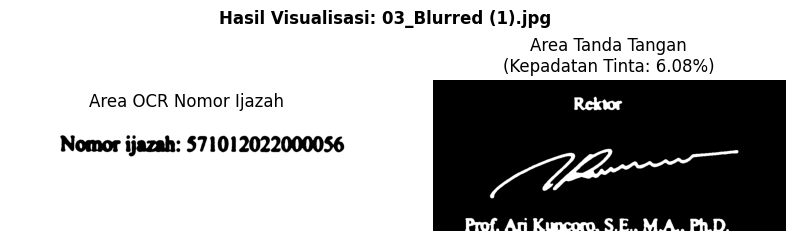

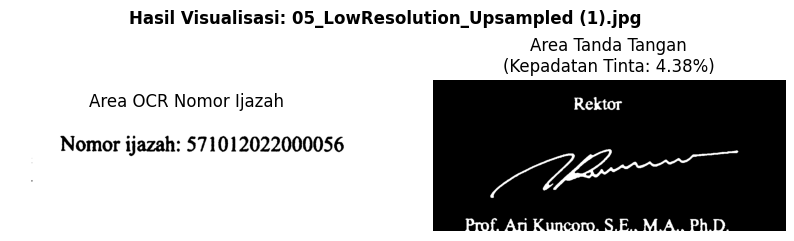

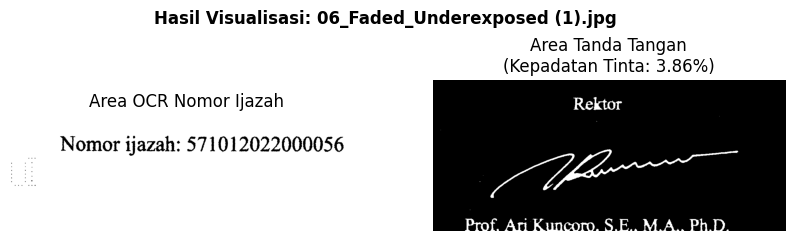

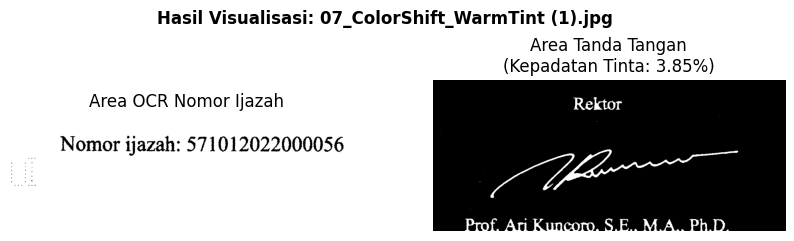

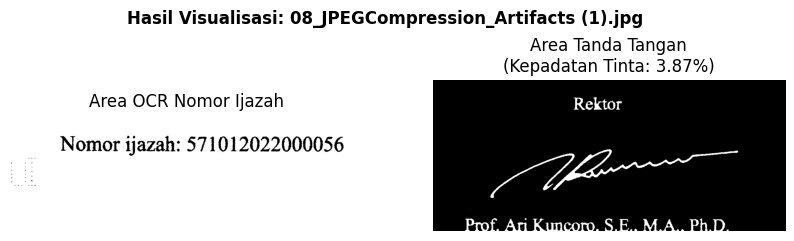

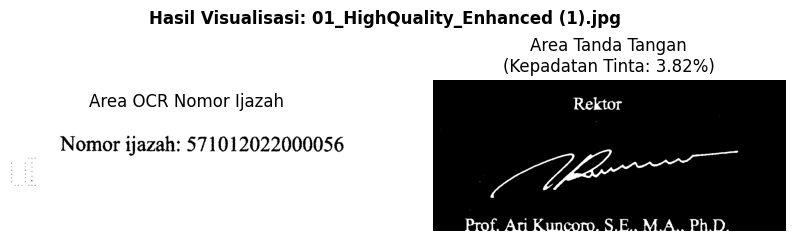

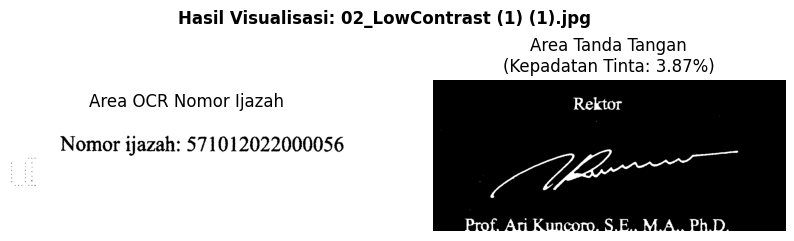

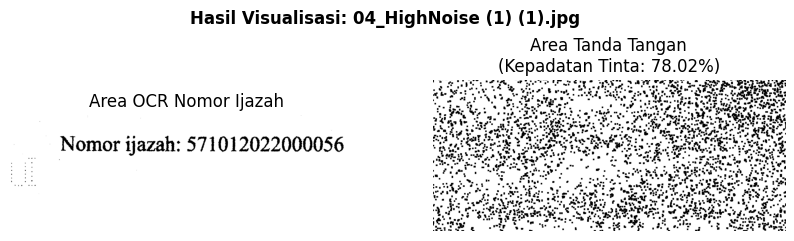

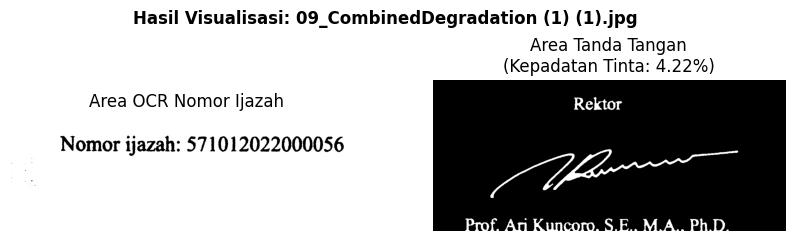

In [90]:
# ==========================================
# SEL 8: VISUALISASI PERBANDINGAN
# ==========================================
for filename, data in data_ijazah.items():
    if 'thresh_nomor' not in data or 'morph_ttd' not in data:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    fig.suptitle(f"Hasil Visualisasi: {filename}", fontsize=12, fontweight='bold')

    ax[0].imshow(data['thresh_nomor'], cmap='gray')
    ax[0].set_title('Area OCR Nomor Ijazah')
    ax[0].axis('off')

    ax[1].imshow(data['morph_ttd'], cmap='gray')
    ax[1].set_title(f"Area Tanda Tangan\n(Kepadatan Tinta: {data['ink_density']:.2f}%)")
    ax[1].axis('off')

    plt.show()
    print("\n")